In [34]:
# =========================================
# 1. IMPORT LIBRARIES + CHURN THEME
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Show all columns
pd.set_option('display.max_columns', None)

# =========================================
# 🎯 CUSTOMER CHURN PROFESSIONAL THEME
# =========================================

# Colors for churn analysis
CHURN_RED = "#E74C3C"      # Churn = Risk
NO_CHURN_BLUE = "#3498DB"  # No Churn = Safe
NEUTRAL_GREY = "#7F8C8D"   # Other info

# Clean professional style
sns.set_theme(style="whitegrid")

# Set palette
sns.set_palette([CHURN_RED, NO_CHURN_BLUE, NEUTRAL_GREY])

# Background settings
plt.rcParams['figure.facecolor'] = "white"
plt.rcParams['axes.facecolor'] = "white"
plt.rcParams['axes.edgecolor'] = "black"
plt.rcParams['axes.labelcolor'] = "black"
plt.rcParams['xtick.color'] = "black"
plt.rcParams['ytick.color'] = "black"
plt.rcParams['text.color'] = "black"

In [35]:
# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [37]:
# =========================================
# 3. DATA UNDERSTANDING
# =========================================
df.info()

print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
# =========================================
# 4. DATA CLEANING
# =========================================

# Convert TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop ID column
df.drop('customerID', axis=1, inplace=True)

print("Data Cleaning Completed ✔")

Data Cleaning Completed ✔


In [39]:
# =========================================
# 5. FEATURE ENGINEERING
# =========================================

# Tenure Group
def tenure_group(x):
    if x <= 12:
        return '0-12 Months'
    elif x <= 24:
        return '12-24 Months'
    elif x <= 48:
        return '24-48 Months'
    else:
        return '48+ Months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

# Service Count
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

df['ServiceCount'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

In [40]:
# =========================================
# 6. BASIC ENCODING (ONLY FOR HEATMAP)
# =========================================
df_encoded = df.copy()

df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# Convert categorical → numeric for heatmap
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

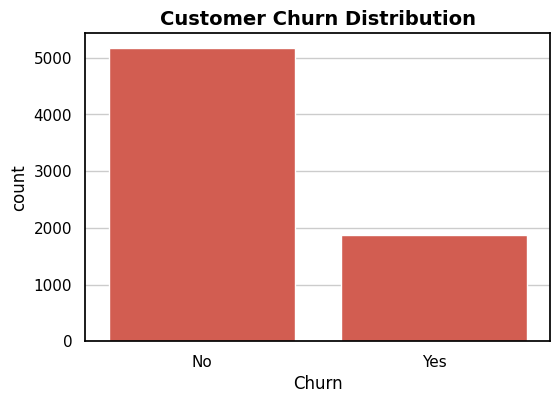

In [41]:
# =========================================
# 7. CHURN DISTRIBUTION
# =========================================
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution", fontsize=14, weight='bold')
plt.show()

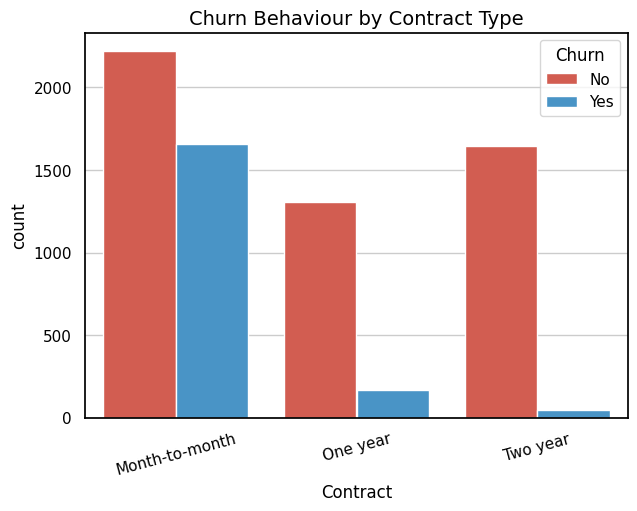

In [42]:
# =========================================
# 8. CONTRACT TYPE VS CHURN
# =========================================
plt.figure(figsize=(7,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn Behaviour by Contract Type", fontsize=14)
plt.xticks(rotation=15)
plt.show()

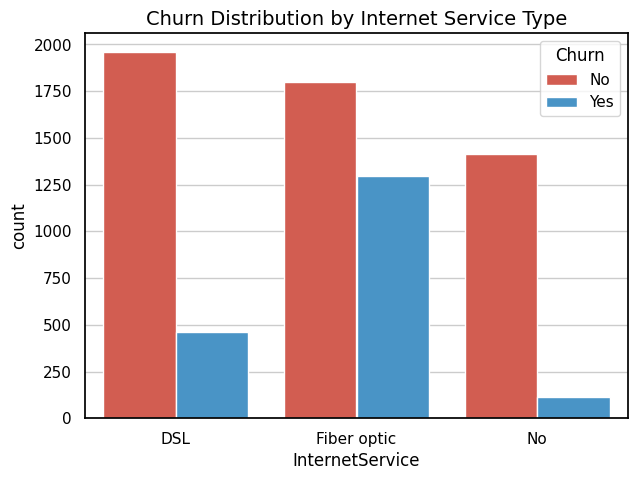

In [43]:
# =========================================
# 9. INTERNET SERVICE VS CHURN
# =========================================
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn Distribution by Internet Service Type", fontsize=14)
plt.show()

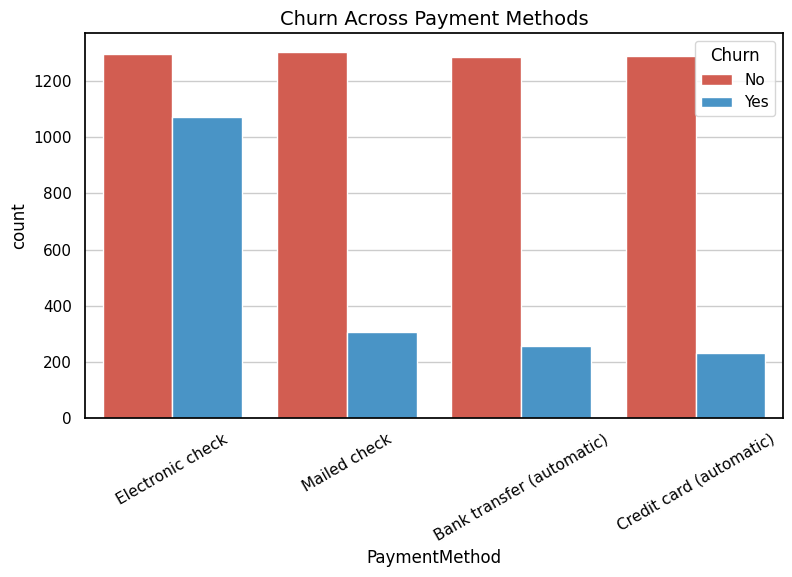

In [44]:
# =========================================
# 10. PAYMENT METHOD VS CHURN
# =========================================
plt.figure(figsize=(9,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn Across Payment Methods", fontsize=14)
plt.xticks(rotation=30)
plt.show()

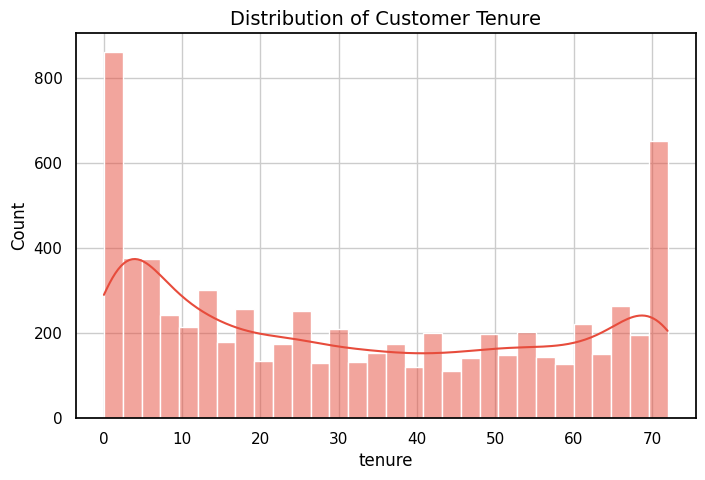

In [45]:
# =========================================
# 11. TENURE DISTRIBUTION
# =========================================
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Distribution of Customer Tenure", fontsize=14)
plt.show()

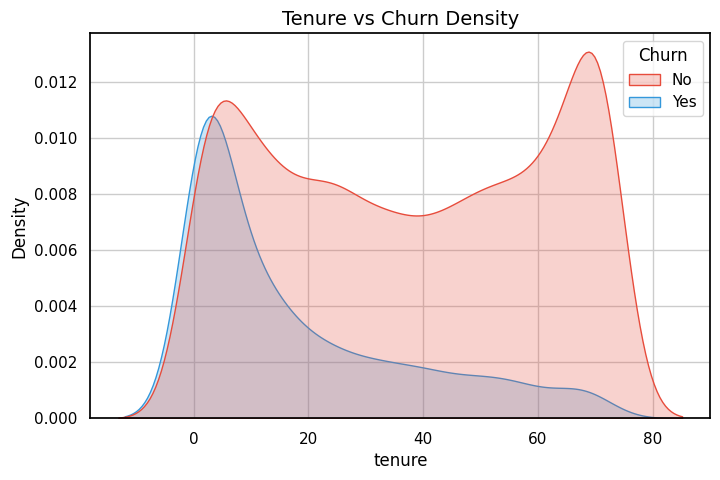

In [46]:
# =========================================
# 12. TENURE VS CHURN
# =========================================
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)
plt.title("Tenure vs Churn Density", fontsize=14)
plt.show()

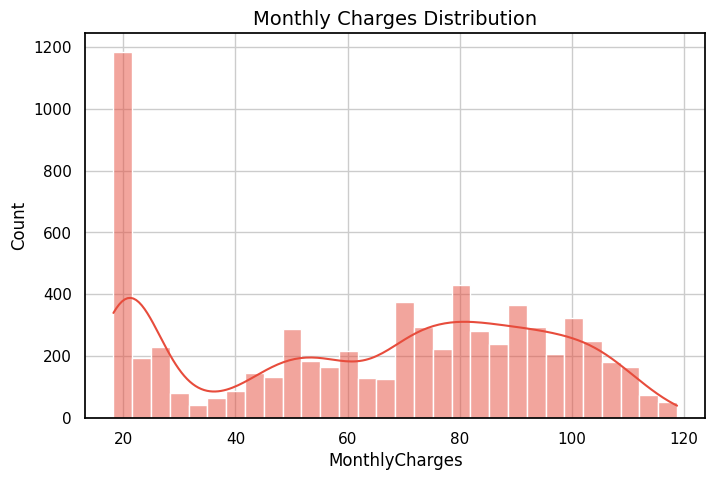

In [47]:
# =========================================
# 13. MONTHLY CHARGES DISTRIBUTION
# =========================================
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution", fontsize=14)
plt.show()

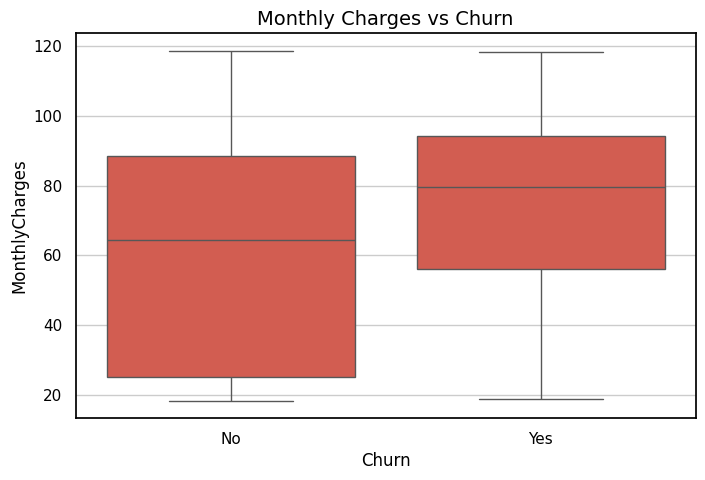

In [48]:
# =========================================
# 14. MONTHLY CHARGES VS CHURN
# =========================================
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn", fontsize=14)
plt.show()


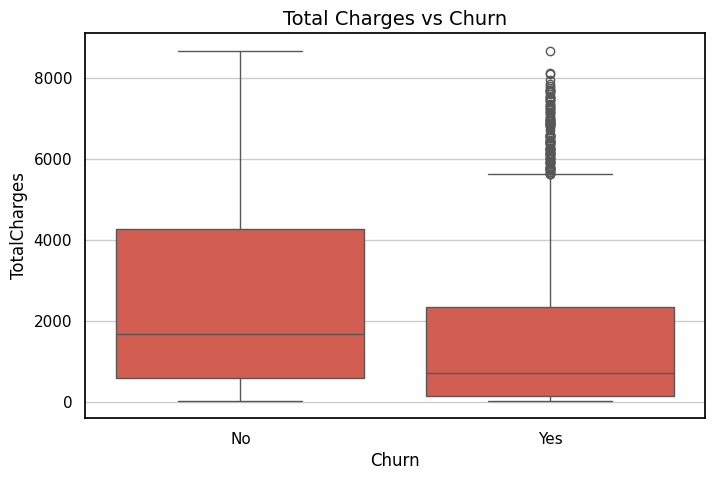

In [49]:
# =========================================
# 15. TOTAL CHARGES VS CHURN
# =========================================
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title("Total Charges vs Churn", fontsize=14)
plt.show()

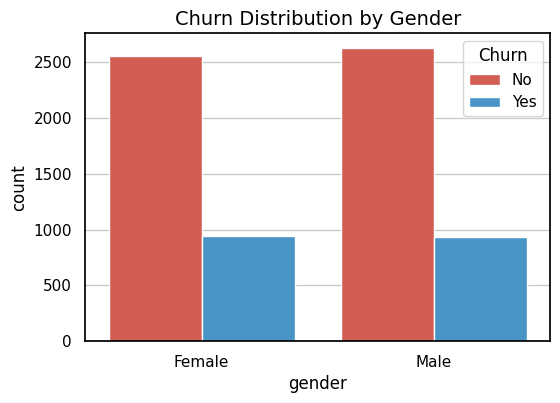

In [50]:
# =========================================
# 16. GENDER VS CHURN
# =========================================
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Churn Distribution by Gender", fontsize=14)
plt.show()

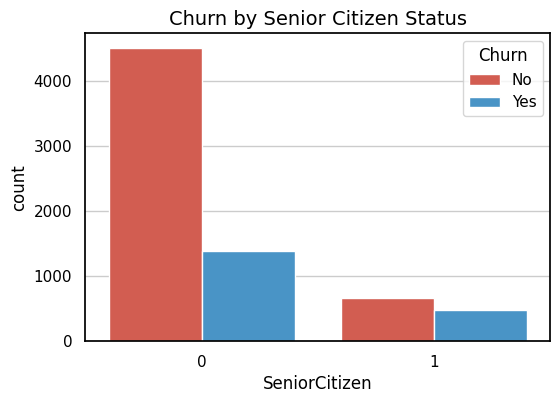

In [51]:
# =========================================
# 17. SENIOR CITIZEN VS CHURN
# =========================================
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Churn by Senior Citizen Status", fontsize=14)
plt.show()

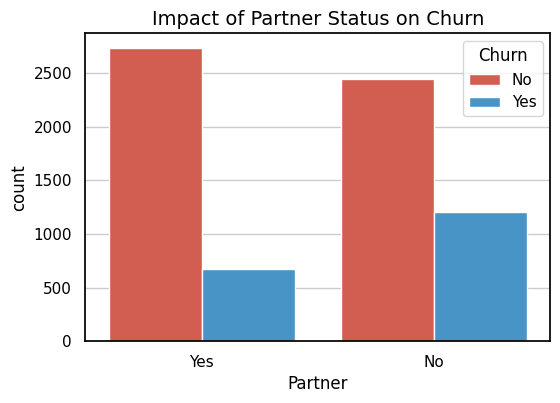

In [52]:
# =========================================
# 18. PARTNER VS CHURN
# =========================================
plt.figure(figsize=(6,4))
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title("Impact of Partner Status on Churn", fontsize=14)
plt.show()

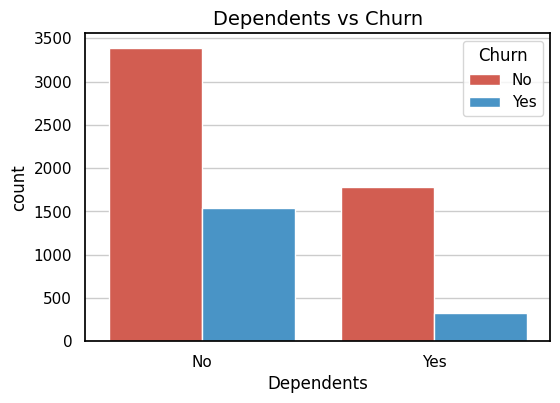

In [53]:
# =========================================
# 19. DEPENDENTS VS CHURN
# =========================================
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title("Dependents vs Churn", fontsize=14)
plt.show()

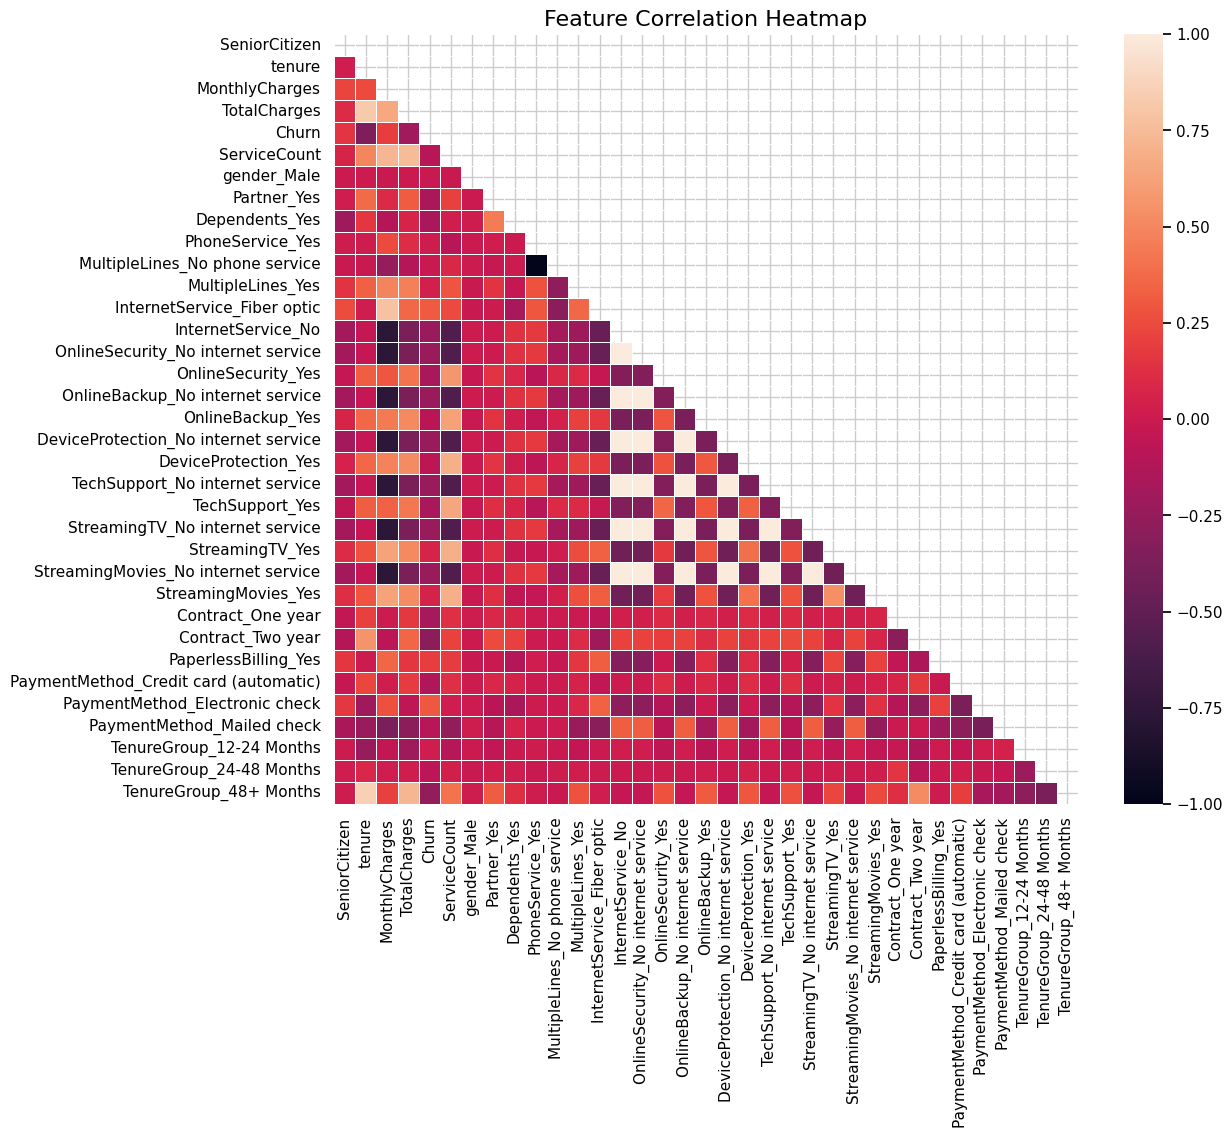

In [54]:
# =========================================
# 20. CORRELATION HEATMAP
# =========================================
plt.figure(figsize=(12,10))

corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap="rocket", linewidths=0.5)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

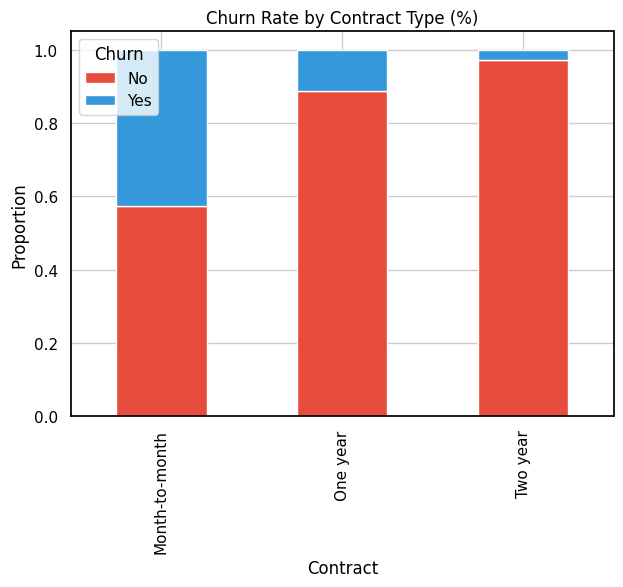

In [55]:
# =========================================
# 21. BONUS: CHURN RATE (%)
# =========================================
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index')

contract_churn.plot(kind='bar', stacked=True, figsize=(7,5))

plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Proportion")
plt.show()

In [56]:
# =========================================
# 22. PREPARE DATA FOR MACHINE LEARNING
# =========================================
df_ml = df.copy()

# Encode target
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

# Convert categorical → numeric
df_ml = pd.get_dummies(df_ml, drop_first=True)

print("ML Dataset Ready ✔")

ML Dataset Ready ✔


In [57]:
# =========================================
# 23. MODEL BUILDING
# =========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# 🔹 Separate features and target
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# 🔹 Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 🔹 Train-Test Split (use scaled data)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# 🔹 Model Training
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# 🔹 Predictions
y_pred = model.predict(X_test)

# 🔹 Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7885024840312278

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



In [58]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7885024840312278

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



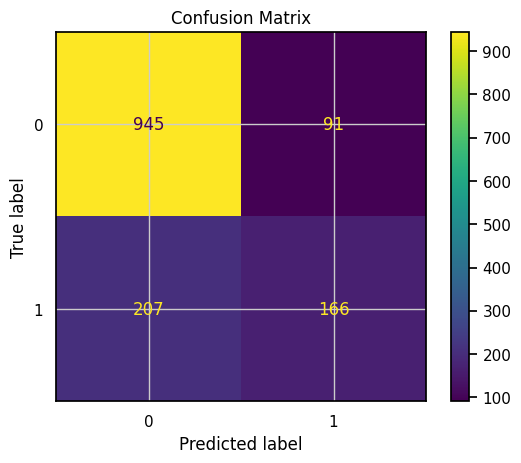

In [59]:
# =========================================
# CONFUSION MATRIX
# =========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

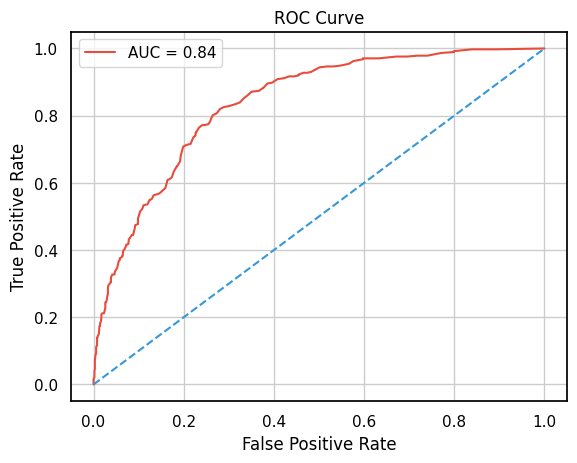

In [60]:
# =========================================
# ROC CURVE
# =========================================
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

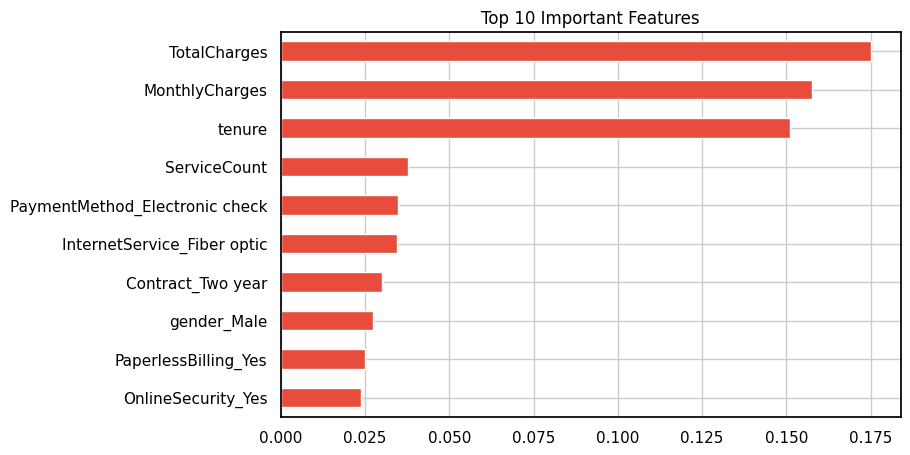

In [61]:
# =========================================
# 24. FEATURE IMPORTANCE
# =========================================
importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='barh')

plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [62]:
# =========================================
# 25. FINAL INSIGHTS
# =========================================
print("\n🔍 KEY INSIGHTS:")
print("• Customers with low tenure are more likely to churn.")
print("• Higher monthly charges increase churn risk.")
print("• Customers using multiple services show higher retention.")
print("• Contract type strongly influences churn.")
print("• Model confirms tenure and charges as key drivers.")


🔍 KEY INSIGHTS:
• Customers with low tenure are more likely to churn.
• Higher monthly charges increase churn risk.
• Customers using multiple services show higher retention.
• Contract type strongly influences churn.
• Model confirms tenure and charges as key drivers.
